In [36]:
from astropy.table import Table

old_tbl = Table.read('/home/vwetzell/Documents/proper_motions/RetII/DES0331-5457.finalcut.cat')

new_tbl = Table.read('/home/vwetzell/Documents/proper_motions/RetII/DES0331-5457.finalcut_updated.cat')

In [37]:
import numpy as np

DEGREE = np.pi / 180.0  # 1 degree, in radians
ARCSEC = DEGREE / 3600.0  # 1 arcsec, in radians


def projectGnomonic(ra, dec, ra0, dec0):
    """Project ra, dec into gnomonic system about ra0, dec0.
    Inputs are in degrees, outputs in arcsec."""
    z = np.sin(dec * DEGREE)
    rho = np.cos(dec * DEGREE)
    ca = np.cos((ra - ra0) * DEGREE)  # cos(alpha) from ref RA
    sa = np.sin((ra - ra0) * DEGREE)
    x = ca * rho
    y = sa * rho
    sd = np.sin(dec0 * DEGREE)
    cd = np.cos(dec0 * DEGREE)
    denom = sd * z + cd * rho * ca
    x = sa * rho / denom
    y = (z * cd - rho * sd * ca) / denom
    return x / ARCSEC, y / ARCSEC

new_tbl["ALPHAWIN_J2000"] = new_tbl["ALPHAWIN_J2000_1"]
new_tbl["DELTAWIN_J2000"] = new_tbl["DELTAWIN_J2000_1"]
new_tbl["EXPNUM"] = new_tbl["EXPNUM_2"]
new_tbl["BAND"] = new_tbl["BAND_2"]

new_tbl.remove_columns(
    [
        "ALPHAWIN_J2000_2",
        "DELTAWIN_J2000_2",
        "ALPHAWIN_J2000_1",
        "DELTAWIN_J2000_1",
        "EXPNUM_2",
        "EXPNUM_1",
        "FILENAME",
        "BAND_1",
        "BAND_2",
    ]
)

xi, eta = projectGnomonic(
    new_tbl["ALPHAWIN_J2000"],
    new_tbl["DELTAWIN_J2000"],
    temp_fc.meta["RA0"],
    temp_fc.meta["DEC0"],
)
new_tbl["XI"] = xi / 3600
new_tbl["ETA"] = eta / 3600

new_tbl.meta = old_tbl.meta


In [38]:
new_tbl.write('/home/vwetzell/Documents/proper_motions/RetII/DES0331-5457.finalcut_updated.cat', format='fits', overwrite=True)

In [2]:
slow_pm = Table.read("/home/vwetzell/Documents/proper_motions/RetII/DES0331-5457.finalcut_updated_slow_movers.fits")
# modest_pm = Table.read("/home/vwetzell/Documents/proper_motions/RetII/DES0331-5457.finalcut_updated_modest_movers.fits")

In [3]:
slow_pm

idx,mtype,xi,eta,ra,dec,pm,pmra,pmdec,parallax,chisqTotal,dof,nClip,c_xx,c_yy,c_vxvx,c_vyvy,c_pipi,c_xy,c_xvx,c_xvy,c_xpi,c_yvx,c_yvy,c_ypi,c_vxvy,c_vxpi,c_vypi,g_mag,r_mag,i_mag,z_mag,Y_mag,g_i_mag,g_n,r_n,i_n,z_n,Y_n,g_spread,r_spread,i_spread,z_spread,Y_spread,g_spread_err,r_spread_err,i_spread_err,z_spread_err,Y_spread_err
,,,,deg,deg,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,bytes4,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,slow,0.21623039893462354,-0.043018199700492143,54.31795383789307,-54.08906585974841,13.5556853736599,-8.604995055396428,-10.4742859444575,-0.0014713012072033803,54.88620513262585,113.0,2.0,0.00014155763841530153,0.00047264273539644784,3.971766316116546e-05,3.8118528945282475e-05,0.0005126676174027376,8.870683086207813e-05,-2.607052722076308e-05,-7.546610132737756e-08,0.0001065672743206874,-2.209054445588284e-05,-2.09525754017763e-05,0.0004266062451519543,5.5303694932346726e-08,-2.6593593154901696e-05,-5.523793141443289e-07,--,23.892691470730398,22.849375100609194,22.145069812763452,21.918924373877537,0.6,0.0,23.0,25.0,9.0,2.0,--,3.419519998715259e-05,0.001988729927688837,0.003089810023084283,-0.00442397000733763,--,0.008132180199027061,0.006217319983989,0.0048166299238801,0.05322975059971213
1,slow,0.21362915967431667,-0.04093328452233337,54.3135006824613,-54.086994462121226,17.301354537163448,-3.4329070337730814,-16.957358819052498,0.029528495000277398,22.527776931810248,49.0,0.0,0.0002675445151010117,0.0009624447783945651,4.451632750098717e-05,4.3255110916355424e-05,0.0011119734189732075,0.00025427675229781953,-1.509975170479226e-05,2.4030538712542606e-06,0.00030370038507882154,-2.9562676956358377e-05,1.8322758472224882e-06,0.0009305343935867293,-2.1810048521995136e-07,-3.544881140864847e-05,8.42533755282251e-06,--,23.896152631111427,22.8498810452204,22.263072282174708,--,0.6,0.0,5.0,10.0,12.0,0.0,--,-6.374459917424247e-05,0.0010861500049941242,0.0034068250097334385,--,--,0.008715559728443623,0.005182720022276044,0.005023529985919595,--
2,slow,0.2106852510885306,-0.04418881899491133,54.308510014364344,-54.09026498236274,7509.003698397454,-7500.631032550451,354.5005727608983,-10.710846136027513,2.9505874460875763,27.0,0.0,0.000488143834578252,0.002521518723462474,0.0001879706450191467,0.0001671739844711881,0.0028442575473479666,0.00011304803049953559,4.8475454912516334e-05,-5.121183331443975e-06,0.00013303013375337734,0.00022388910892134464,-6.190575033426817e-05,0.0024109161762326946,-1.0697048720723307e-05,0.0002638434151737455,-0.00011471188416425019,24.170999299526315,23.884864314314772,22.77544171739893,--,--,1.3955575821273847,2.0,10.0,4.0,0.0,0.0,0.0026802601059898734,0.004985035164281726,0.0024992864346131682,--,--,0.007498574908822775,0.00729943485930562,0.006322214845567942,--,--
3,slow,0.23716963521266834,-0.044032600462079984,54.353662950778336,-54.0899658306913,317.2247763025659,198.86183056409834,247.15487258985775,0.07714638226689051,98.02150846191951,135.0,9.0,8.156331477993736e-06,3.394351772419625e-05,3.91426258802548e-06,3.021688103906371e-06,4.005174296996965e-05,3.8534786600571744e-06,-1.3850134674848113e-07,-7.216544462311298e-08,4.778430322370783e-06,-4.682515010225459e-06,2.959431831596168e-07,3.227879962238405e-05,9.115785705774021e-08,-5.81738511668449e-06,-6.542616372066139e-07,23.608761465386067,23.771976386855528,22.829330465428335,22.478846902301946,--,0.7794309999577322,8.0,23.0,21.0,18.0,0.0,0.005388804944232106,0.003816640004515648,0.004926980007439852,0.0006142799975350499,--,0.004924699896946549,0.007102979812771082,0.005586190149188042,0.007087825099006295,--
4,slow,0.23870023960770864,-0.04055554919575782,

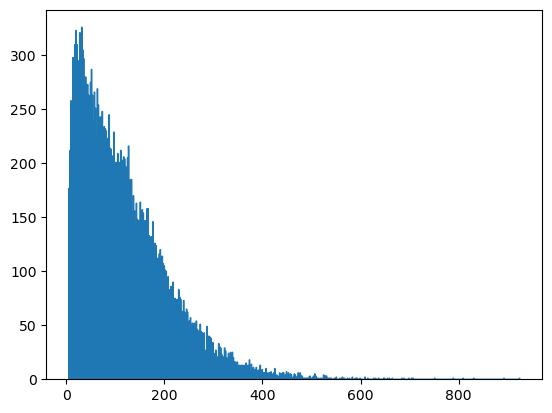

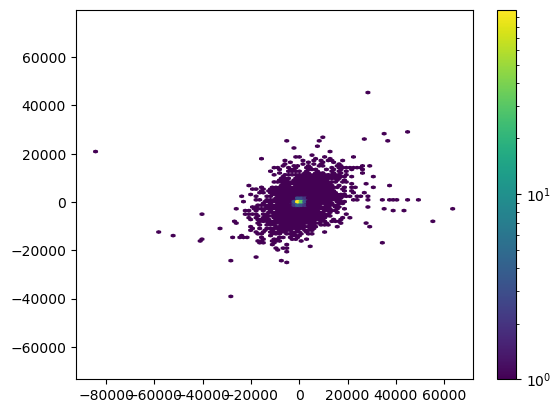

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

plt.figure()
plt.hist(slow_pm['dof'],bins=int(np.max(slow_pm['dof'])),histtype='step')
plt.show()

plt.figure()
plt.axis('equal')
plt.hexbin(slow_pm['pmra'],slow_pm['pmdec'],bins=100,norm=LogNorm())
plt.colorbar()
plt.show()

In [5]:
old_tbl[:5]

NameError: name 'old_tbl' is not defined

In [ ]:
new_tbl[:5]

CCDNUM,FLAGS,IMAFLAGS_ISO,XWIN_IMAGE,YWIN_IMAGE,ERRAWIN_WORLD,ERRBWIN_WORLD,ERRTHETAWIN_J2000,SPREAD_MODEL,SPREADERR_MODEL,FLUX_AUTO,FLUXERR_AUTO,XI,ETA,MJD,PAR_XI,PAR_ETA,RA_ERR,DEC_ERR,ALPHAWIN_J2000,DELTAWIN_J2000,EXPNUM,BAND
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bytes1
55,17,8192,2030.4259033203125,3410.356201171875,2.3246000637300313e-05,2.3174799935077317e-05,37.81290054321289,-0.001430050004273653,0.006114630028605461,2783.0,476.4599914550781,-0.3583511245900387,-0.09645710593053246,56592.36762092092,0.3542107957500386,-0.8638873899011851,1.7692180696386848e-06,1.508505180887623e-06,52.36574471542726,-55.04763173246837,247324,Y
55,2,16384,2014.593505859375,3967.742431640625,4.366990106063895e-05,4.342570173321292e-05,61.48400115966797,0.012456499971449375,0.008166559971868992,5756.83984375,1063.6300048828125,-0.31774671354703604,-0.09414598389757689,56592.36762092092,0.3542107957500386,-0.8638873899011851,1.907570141195069e-06,1.6455558466693008e-06,52.436647696971725,-55.04566345987325,247324,Y
55,0,0,1997.1312255859375,3728.222412109375,5.1653798436746e-05,5.146579860593192e-05,47.641700744628906,-0.011309100314974785,0.011886400170624256,2579.8701171875,703.573974609375,-0.33524090883748214,-0.09336455779228196,56592.36762092092,0.3542107957500386,-0.8638873899011851,1.7481522336341821e-06,1.5267963257547678e-06,52.40612623812137,-55.04473946983658,247324,Y
55,0,0,1997.1312255859375,3728.222412109375,5.1653798436746e-05,5.146579860593192e-05,47.641700744628906,-0.011309100314974785,0.011886400170624256,2579.8701171875,703.573974609375,-0.33713598970792386,-0.08999066943142182,56592.36762092092,0.3542107957500386,-0.8638873899011851,1.7503423752081152e-06,1.508833931391e-06,52.402868317590645,-55.04134986154574,247324,Y
55,0,0,1950.082763671875,3703.418212890625,3.4566899557830766e-05,3.449169889790937e-05,49.31549835205078,0.016669800505042076,0.004861670080572367,11566.7998046875,1276.1600341796875,-0.33524090883748214,-0.09336455779228196,56592.36762092092,0.3542107957500386,-0.8638873899011851,1.7481522336341821e-06,1.5267963257547678e-06,52.40612623812137,-55.04473946983658,247324,Y


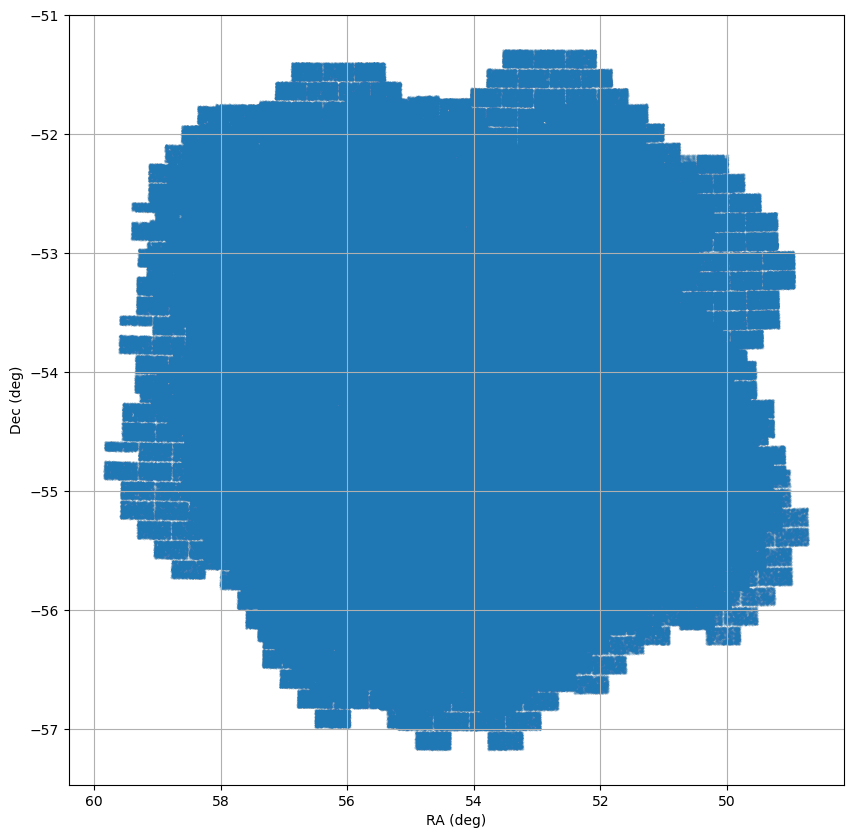

In [39]:
from astropy.table import Table, vstack, join, join_skycoord
import astropy.units as u
from astropy.coordinates import SkyCoord
import glob
import matplotlib.pyplot as plt
import numpy as np

tbl_ls = []

DEGREE = np.pi / 180.0  # 1 degree, in radians
ARCSEC = DEGREE / 3600.0  # 1 arcsec, in radians


def projectGnomonic(ra, dec, ra0, dec0):
    """Project ra, dec into gnomonic system about ra0, dec0.
    Inputs are in degrees, outputs in arcsec."""
    z = np.sin(dec * DEGREE)
    rho = np.cos(dec * DEGREE)
    ca = np.cos((ra - ra0) * DEGREE)  # cos(alpha) from ref RA
    sa = np.sin((ra - ra0) * DEGREE)
    x = ca * rho
    y = sa * rho
    sd = np.sin(dec0 * DEGREE)
    cd = np.cos(dec0 * DEGREE)
    denom = sd * z + cd * rho * ca
    x = sa * rho / denom
    y = (z * cd - rho * sd * ca) / denom
    return x / ARCSEC, y / ARCSEC


def inverseGnomonic(xi, eta, ra0, dec0, deg=True):
    # Convert to radians if needed
    if deg:
        factor = np.pi / 180.0
        xi = np.asarray(xi) * factor
        eta = np.asarray(eta) * factor
        ra0 = np.asarray(ra0) * factor
        dec0 = np.asarray(dec0) * factor
    else:
        xi = np.asarray(xi)
        eta = np.asarray(eta)
        ra0 = np.asarray(ra0)
        dec0 = np.asarray(dec0)

    rho = np.hypot(xi, eta)
    # To avoid division by zero at the projection center
    c = np.arctan(rho)
    sin_c = np.sin(c)
    cos_c = np.cos(c)

    # Declination
    dec = np.arcsin(
        cos_c * np.sin(dec0) + (eta * sin_c * np.cos(dec0) / np.where(rho == 0, 1, rho))
    )

    # Right ascension
    numerator = xi * sin_c
    denominator = rho * np.cos(dec0) * cos_c - eta * np.sin(dec0) * sin_c
    ra = ra0 + np.arctan2(numerator, denominator)

    # Normalize RA into [0, 2π)
    ra = np.mod(ra, 2 * np.pi)

    if deg:
        ra = np.degrees(ra)
        dec = np.degrees(dec)

    return ra, dec


for fn in glob.glob("/home/vwetzell/Documents/proper_motions/RetII/gpr_*.fits"):
    temp_tbl = Table.read(fn)

    expnum = fn[-12:-5]

    ra0 = temp_tbl.meta["RA0"]
    dec0 = temp_tbl.meta["DEC0"]

    new_ra, new_dec = inverseGnomonic(
        (temp_tbl["xieta"][:, 0] - temp_tbl["uv_model"][:, 0]) / 3600.0,
        (temp_tbl["xieta"][:, 1] - temp_tbl["uv_model"][:, 1]) / 3600.0,
        ra0,
        dec0,
    )

    old_ra, old_dec = inverseGnomonic(
        (temp_tbl["xieta"][:, 0]) / 3600.0,
        (temp_tbl["xieta"][:, 1]) / 3600.0,
        ra0,
        dec0,
    )

    new_tbl = Table()
    # new_tbl["SKYCOORD"] = SkyCoord(
    #     ra=new_ra * u.deg,
    #     dec=new_dec * u.deg,
    #     frame="icrs",
    # )
    # new_tbl["OLD_SKYCOORD"] = SkyCoord(
    #     ra=old_ra * u.deg,
    #     dec=old_dec * u.deg,
    #     frame="icrs",
    # )
    # new_tbl["XI"] = temp_tbl["xieta"][:, 0]
    # new_tbl["ETA"] = temp_tbl["xieta"][:, 1]
    new_tbl["OLD_ALPHAWIN_J2000"] = old_ra
    new_tbl["OLD_DELTAWIN_J2000"] = old_dec
    new_tbl["ALPHAWIN_J2000"] = new_ra
    new_tbl["DELTAWIN_J2000"] = new_dec
    new_tbl["RA_ERR"] = temp_tbl["cov_model"][:, 0, 0] ** 0.5 / 3600.0
    new_tbl["DEC_ERR"] = temp_tbl["cov_model"][:, 1, 1] ** 0.5 / 3600.0
    new_tbl["BAND"] = np.repeat(temp_tbl.meta["FILTER"], len(new_tbl))
    new_tbl["EXPNUM"] = np.repeat(int(expnum), len(new_tbl))

    tbl_ls.append(new_tbl)

tbl = vstack(tbl_ls)

del tbl_ls

tbl.write("/home/vwetzell/Documents/proper_motions/RetII/RetII_updated.fits", format="fits", overwrite=True)

plt.figure(figsize=(10, 10))
plt.scatter(tbl["ALPHAWIN_J2000"], tbl["DELTAWIN_J2000"], s=0.1, alpha=0.1)
plt.gca().invert_xaxis()
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.grid()
plt.show()

In [28]:
import tqdm

join_func = join_skycoord(5 * u.arcsec)

for fn in tqdm.tqdm(
    glob.glob("/home/vwetzell/Documents/proper_motions/RetII/DES*finalcut.cat")[:1],
    total=len(
        glob.glob("/home/vwetzell/Documents/proper_motions/RetII/DES*finalcut.cat")[:1]
    ),
):
    finalcut_ls = []
    temp_fc = Table.read(fn)

    for expnum in np.unique(temp_fc["EXPNUM"])[:10]:
        temp_fc_expnum = temp_fc[temp_fc["EXPNUM"] == expnum]
        temp_tbl_expnum = tbl[tbl["EXPNUM"] == expnum]

        fc_skycoord = SkyCoord(
            temp_fc_expnum["ALPHAWIN_J2000"],
            temp_fc_expnum["DELTAWIN_J2000"],
            unit="deg",
        )

        temp_fc_expnum["SKYCOORD"] = fc_skycoord

        try:
            updated_fc = join(
                temp_fc_expnum,
                temp_tbl_expnum,
                keys=["SKYCOORD"],
                join_type="inner",
                join_funcs={"SKYCOORD": join_func},
                table_names=["old", "new"],
                metadata_conflicts="silent",
            )
            if len(updated_fc) == 0:
                print(f"Empty join for {expnum} with {len(temp_fc_expnum)} sources")
                continue
            finalcut_ls.append(updated_fc)

        except ValueError:
            print(f"ValueError for {expnum} with {len(temp_fc_expnum)} sources")
            continue

    finalcut_updated = vstack(finalcut_ls)

    finalcut_updated["ALPHAWIN_J2000"] = finalcut_updated["ALPHAWIN_J2000_new"]
    finalcut_updated["DELTAWIN_J2000"] = finalcut_updated["DELTAWIN_J2000_new"]
    finalcut_updated["EXPNUM"] = finalcut_updated["EXPNUM_old"]
    finalcut_updated["BAND"] = finalcut_updated["BAND_old"]

    finalcut_updated.remove_columns(
        [
            "SKYCOORD_old",
            "SKYCOORD_new",
            "ALPHAWIN_J2000_old",
            "DELTAWIN_J2000_old",
            "ALPHAWIN_J2000_new",
            "DELTAWIN_J2000_new",
            "EXPNUM_old",
            "EXPNUM_new",
            "FILENAME",
            "OLD_SKYCOORD",
            "BAND_new",
            "BAND_old",
            "SKYCOORD_id",
        ]
    )

    xi, eta = projectGnomonic(
        finalcut_updated["ALPHAWIN_J2000"],
        finalcut_updated["DELTAWIN_J2000"],
        temp_fc.meta["RA0"],
        temp_fc.meta["DEC0"],
    )
    finalcut_updated["XI"] = xi / 3600
    finalcut_updated["ETA"] = eta / 3600

    finalcut_updated.meta = temp_fc.meta

    finalcut_updated.write(
        fn.replace(".cat", "_updated.cat"),
        format="fits",
        overwrite=True,
    )

100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


In [29]:
len(finalcut_updated),len(np.unique(finalcut_updated["XWIN_IMAGE"]))

(167879, 125560)

In [26]:
len(np.unique(finalcut_updated["XWIN_IMAGE"]))

125560

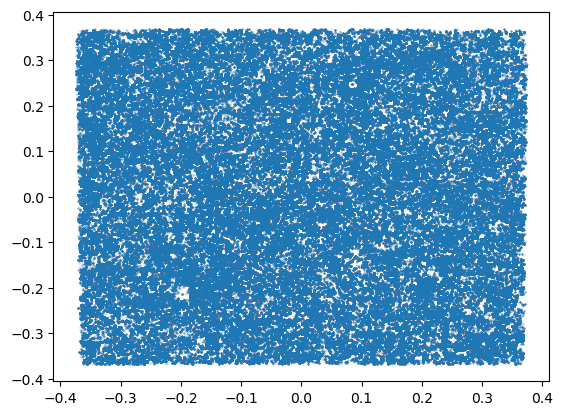

In [7]:
plt.figure()
plt.scatter(
    finalcut_updated["XI"]/3600,
    finalcut_updated["ETA"]/3600,
    s=0.1,
    alpha=0.1,
)
plt.show()

In [5]:
np.sqrt(finalcut_updated["RA_ERR"])

0.0007484626238918794
0.000753651456718925
0.0009043777150228676
0.0007482593734669514
0.0007468551036128738
0.0007486368590295748
0.0007394198346462495
0.0007401752411340696
0.0007378232878435408
0.0007425539635099311
0.0007486011099471545


In [ ]:
del temp_fc
del temp_tbl
del updated_fc
del finalcut_ls
del tbl
del temp_tbl_expnum
del temp_fc_expnum
del tbl_ls

In [5]:
finalcut_updated["ALPHAWIN_J2000"] = finalcut_updated["ALPHAWIN_J2000_new"]
finalcut_updated["DELTAWIN_J2000"] = finalcut_updated["DELTAWIN_J2000_new"]
finalcut_updated["EXPNUM"] = finalcut_updated["EXPNUM_old"]
finalcut_updated["BAND"] = finalcut_updated["BAND_old"]

finalcut_updated.remove_columns(
    [
        "SKYCOORD_old",
        "SKYCOORD_new",
        "ALPHAWIN_J2000_old",
        "DELTAWIN_J2000_old",
        "ALPHAWIN_J2000_new",
        "DELTAWIN_J2000_new",
        "EXPNUM_old",
        "EXPNUM_new",
        "FILENAME",
        "OLD_SKYCOORD",
        "BAND_new",
        "BAND_old",
        "SKYCOORD_id",
    ]
)

NameError: name 'finalcut_updated' is not defined

In [ ]:
finalcut_updated

CCDNUM,FLAGS,IMAFLAGS_ISO,XWIN_IMAGE,YWIN_IMAGE,ERRAWIN_WORLD,ERRBWIN_WORLD,ERRTHETAWIN_J2000,SPREAD_MODEL,SPREADERR_MODEL,FLUX_AUTO,FLUXERR_AUTO,XI,ETA,MJD,PAR_XI,PAR_ETA,RA_ERR,DEC_ERR,ALPHAWIN_J2000,DELTAWIN_J2000,EXPNUM,BAND
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bytes1
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.60196299363117e-07,6.082226506208316e-07,55.820030530923304,-53.885343285954136,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.679905182145576e-07,5.951931729729479e-07,55.82052266083106,-53.8888827572631,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,8.17899051429983e-07,8.832642414005105e-07,55.8157478974765,-53.88453039203221,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.598920899811546e-07,5.888994126095742e-07,55.82239162954101,-53.88735305478488,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.577925457925964e-07,6.017242065317066e-07,55.81623034229851,-53.888634932874155,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.604571466976674e-07,6.2613912510217e-07,55.80552449176355,-53.88204089229488,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.467416918682869e-07,5.816625798327965e-07,55.81123951531104,-53.88750585551744,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.478593875878781e-07,6.050277943195217e-07,55.81190790136347,-53.88525886528301,233629,g
29,0,0,833.7767333984375,3260.202392578125,2.2176500351633877e-05,2.2021700715413317e-05,-36.77920150756836,-0.004056369885802269,0.00501656997948885,978.8079833984375,230.0279998779297,0.18470544560981578,-0.3640533281827452,56548.38627924758,0.9052052127361949,-0.3107543158299399,5.443832040842523e-07,6.047591141634606e-07,55.81091597614096,-53.88376158500956,233629,g


In [ ]:
finalcut_updated.write("/home/vwetzell/Documents/proper_motions/RetII/RetII_finalcut_updated.fits", overwrite=True)

: 

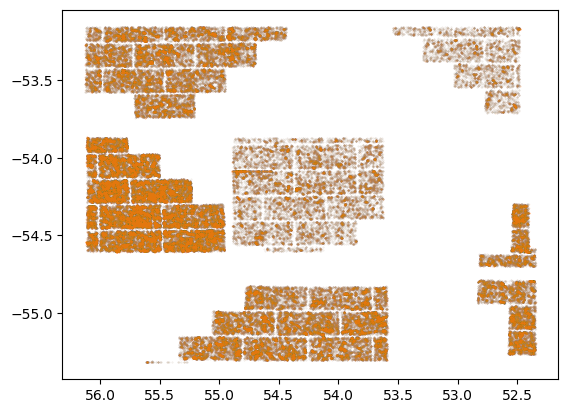

In [14]:
plt.figure()
plt.scatter(finalcut_updated["SKYCOORD_1"].ra.deg, finalcut_updated["SKYCOORD_1"].dec.deg, s=0.1, alpha=0.1)
plt.scatter(finalcut_updated["SKYCOORD_2"].ra.deg, finalcut_updated["SKYCOORD_2"].dec.deg, s=0.1, alpha=0.1)
plt.gca().invert_xaxis()
plt.show()

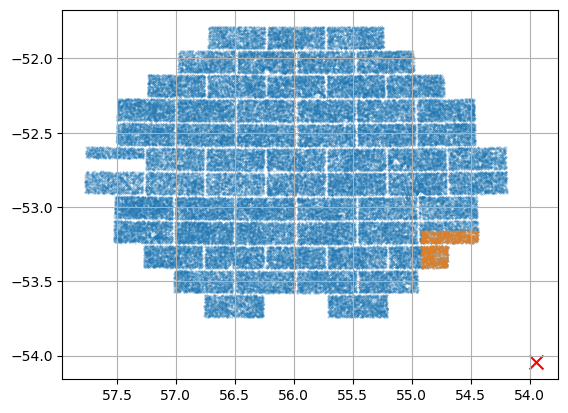

In [15]:
plt.figure()
plt.gca().invert_xaxis()
plt.scatter(temp_tbl_expnum['SKYCOORD'].ra.deg,temp_tbl_expnum['SKYCOORD'].dec.deg ,s=0.1, alpha=0.5)
plt.scatter(temp_fc_expnum['SKYCOORD'].ra.deg,temp_fc_expnum['SKYCOORD'].dec.deg, s=0.1, alpha=0.5)
plt.scatter(53.94929167,-54.0466111, s=100, c="red", marker="x")
plt.grid()
plt.show()

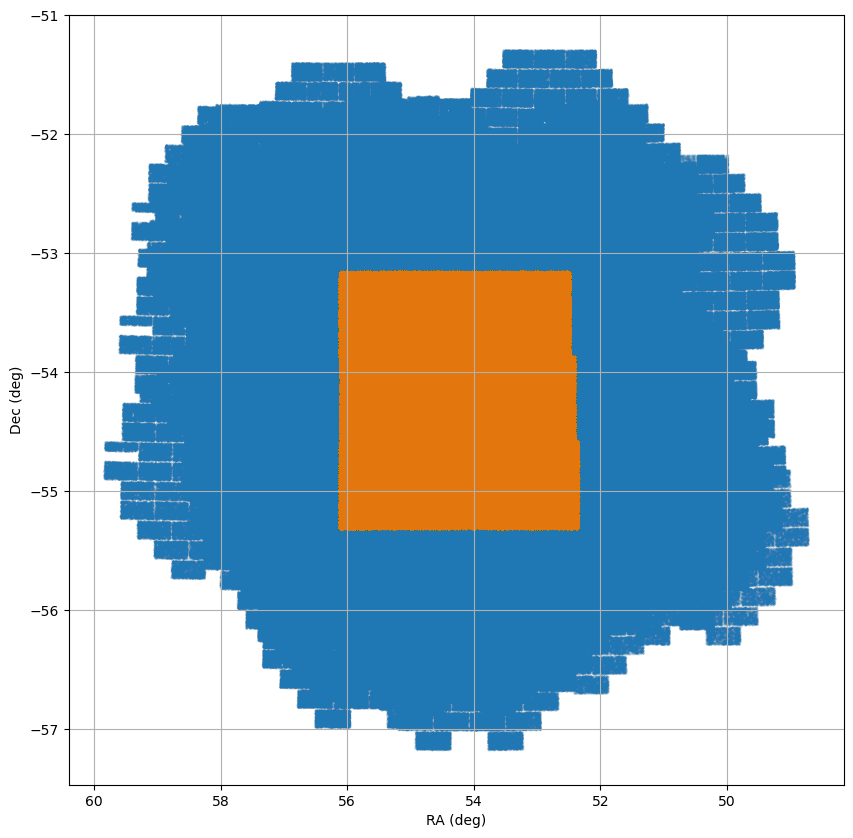

In [18]:
plt.figure(figsize=(10, 10))
# plt.axis("equal")
plt.scatter(tbl["RA"], tbl["DEC"], s=0.1, alpha=0.1)
plt.scatter(
    finalcut_updated["RA"],
    finalcut_updated["DEC"],
    s=0.1,
    alpha=0.1,
)
plt.gca().invert_xaxis()
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.grid()
plt.show()

In [ ]:
DEGREE = np.pi / 180.  # 1 degree, in radians
ARCSEC = DEGREE / 3600.  # 1 arcsec, in radians
def projectGnomonic(ra, dec, ra0, dec0):
    '''Project ra, dec into gnomonic system about ra0, dec0.
    Inputs are in degrees, outputs in arcsec.'''
    z = np.sin(dec*DEGREE)
    rho = np.cos(dec*DEGREE)
    ca = np.cos((ra - ra0)*DEGREE)  # cos(alpha) from ref RA
    sa = np.sin((ra - ra0)*DEGREE)
    x = ca * rho
    y = sa * rho
    sd = np.sin(dec0*DEGREE)
    cd = np.cos(dec0*DEGREE)
    denom = sd*z + cd*rho*ca
    x = sa * rho/denom
    y = (z * cd - rho * sd*ca)/denom
    return x/ARCSEC, y/ARCSEC

def inverseGnomonic(xi, eta, ra0, dec0):
    '''Inverse gnomonic projection. Inputs are in arcsec, outputs in degrees.'''
    xi = xi * ARCSEC
    eta = eta * ARCSEC
    rho = np.sqrt(xi**2 + eta**2)
    z = np.sin(dec0*DEGREE) + np.cos(dec0*DEGREE) * rho
    x = xi * z
    y = eta * z
    denom = np.sqrt(x**2 + y**2)
    x /= denom
    y /= denom
    ra = ra0 + np.arctan2(y, x)/DEGREE
    dec = np.arcsin(z)/DEGREE
    return ra, dec

